In [ ]:
#import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/placementdata.csv")
df.head(5)

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive')


['Getting started.pdf',
 'memories',
 'IMG-20210501-WA0016.jpg',
 'FB_IMG_16223734761953430.jpg',
 'FB_IMG_16223735041732779.jpg',
 'JEE(Main)',
 'Screenshot (99) (1).png',
 'Screenshot (99).png',
 'IMG-20240614-WA0009.jpg',
 '12306729 INT375.pdf',
 'student_habits_performance.csv',
 'Colab Notebooks',
 'placementdata.csv']

In [ ]:
import os

path = os.path.join('/content/drive/MyDrive', 'placementdata.csv')
print(path)


/content/drive/MyDrive/placementdata.csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [ ]:
df.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [ ]:
df.isnull().sum()

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [ ]:
#Handling missing values
df=df.fillna(df.mean(numeric_only=True))   #for numbers
df=df.fillna(df.mode().iloc[0])     #for categories

df=df.drop_duplicates()

le=LabelEncoder()

cat_columns=['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus']
for col in cat_columns:
    df[col]=le.fit_transform(df[col])

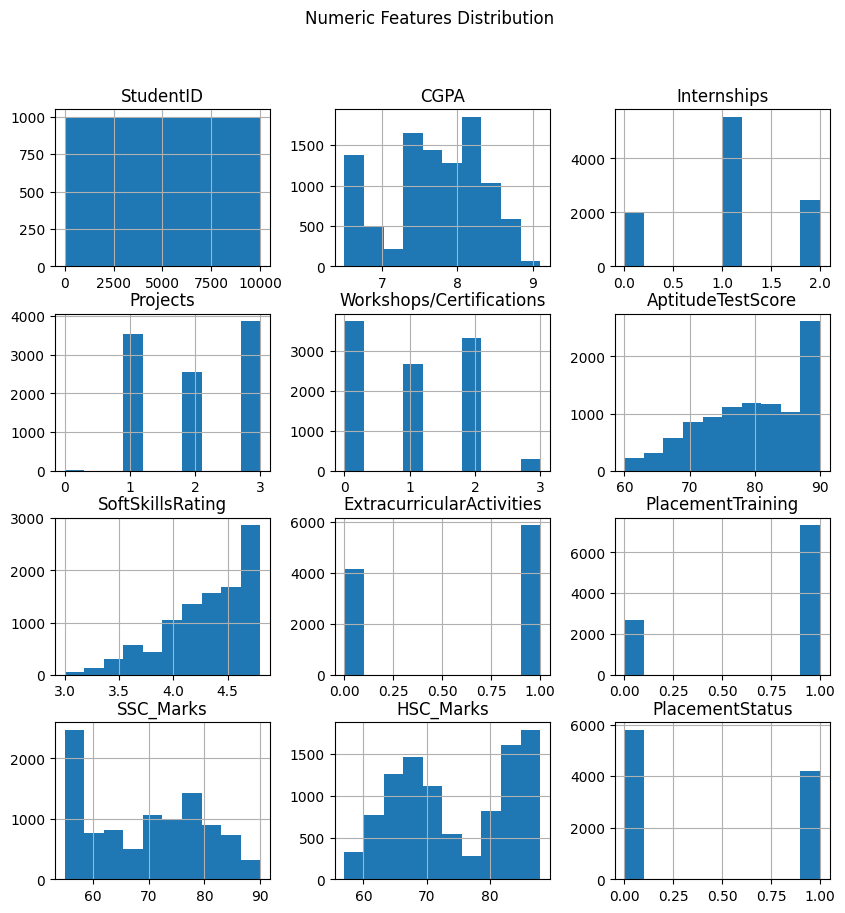

In [ ]:
# Visualization

#Histogram for numeric columns
df.hist(figsize=(10,10))
plt.suptitle("Numeric Features Distribution")
plt.show()

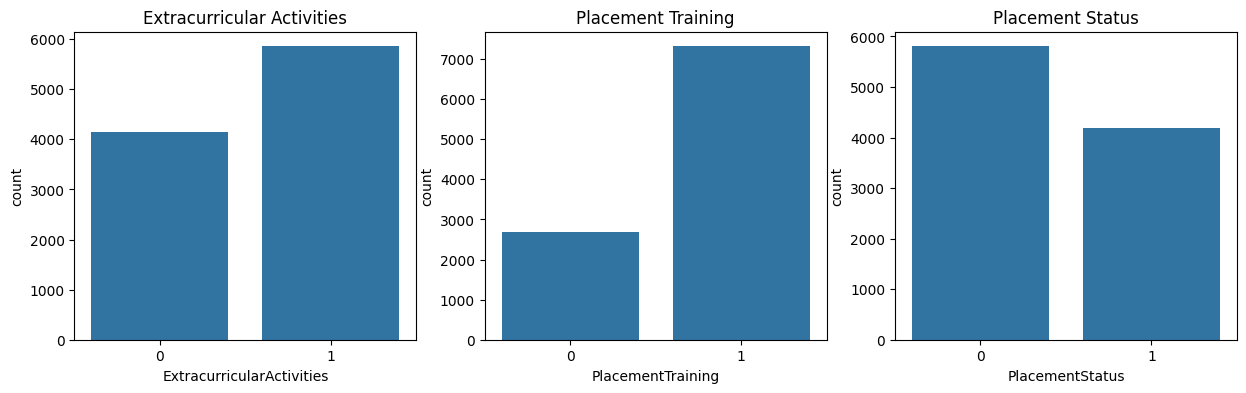

In [ ]:
# Countplot

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.countplot(x='ExtracurricularActivities', data=df)
plt.title("Extracurricular Activities")

plt.subplot(1,3,2)
sns.countplot(x='PlacementTraining',data=df)
plt.title("Placement Training")

plt.subplot(1,3,3)
sns.countplot(x='PlacementStatus', data=df)
plt.title("Placement Status")

plt.show()

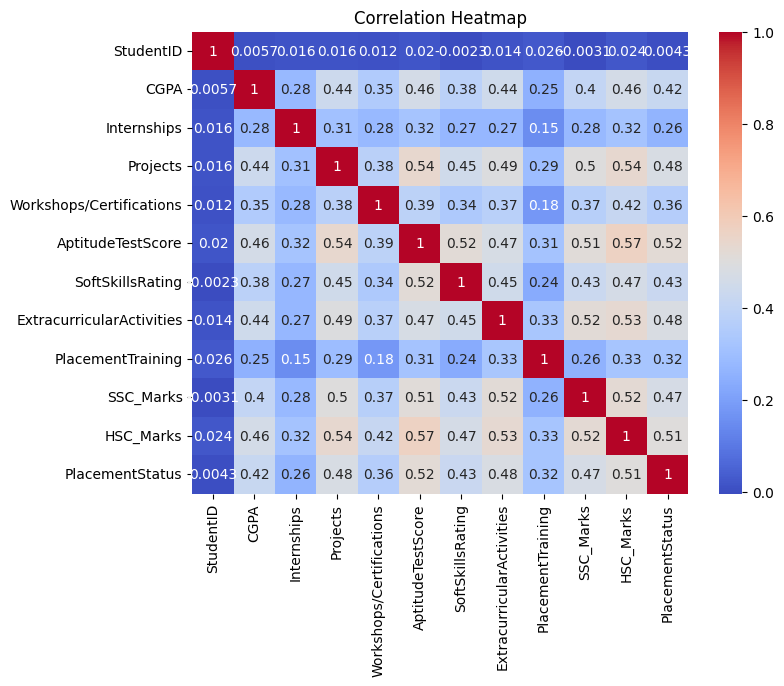

In [ ]:
#correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

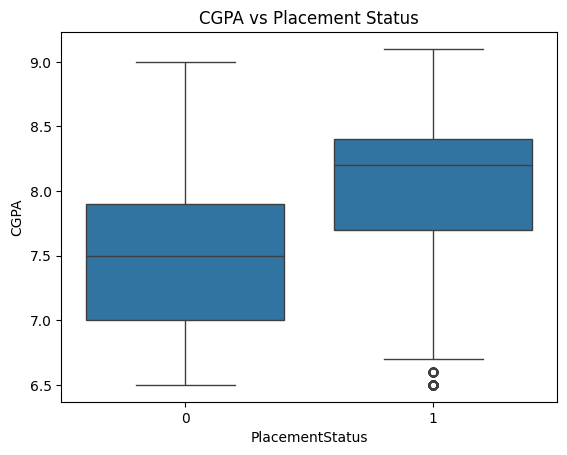

In [ ]:
#boxplot
sns.boxplot(x='PlacementStatus', y='CGPA', data=df)
plt.title("CGPA vs Placement Status")
plt.show()

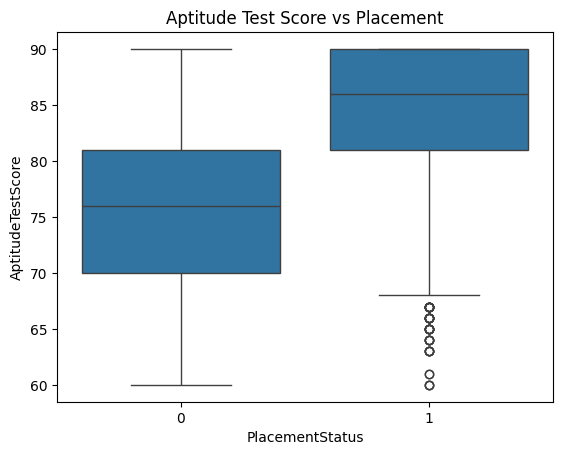

In [ ]:
sns.boxplot(x='PlacementStatus', y='AptitudeTestScore', data=df)
plt.title("Aptitude Test Score vs Placement")
plt.show()

In [ ]:
X=df.drop('PlacementStatus', axis=1)
Y=df['PlacementStatus']

X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Logistic Regression

log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train,Y_train)
log_pred=log_model.predict(X_test)

In [ ]:
#K-Nearest Neighbors(KNN)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, Y_train)
knn_pred = knn_model.predict(X_test)

In [ ]:
#Decision Tree

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, Y_train)
dt_pred = dt_model.predict(X_test)

In [ ]:
#Random Forest

rf_model = RandomForestClassifier()
rf_model.fit(X_train, Y_train)
rf_pred = rf_model.predict(X_test)

In [ ]:
#Naive Bayes

nb_model = GaussianNB()
nb_model.fit(X_train, Y_train)
nb_pred = nb_model.predict(X_test)

In [ ]:
results = {
    'Logistic Regression': accuracy_score(Y_test, log_pred),
    'KNN': accuracy_score(Y_test, knn_pred),
    'Decision Tree': accuracy_score(Y_test, dt_pred),
    'Random Forest': accuracy_score(Y_test, rf_pred),
    'Naive Bayes': accuracy_score(Y_test, nb_pred)
}

for model, acc in results.items():
    print(model, "Accuracy:", round(acc * 100, 2), "%")

Logistic Regression Accuracy: 79.35 %
KNN Accuracy: 77.1 %
Decision Tree Accuracy: 71.95 %
Random Forest Accuracy: 78.55 %
Naive Bayes Accuracy: 79.35 %


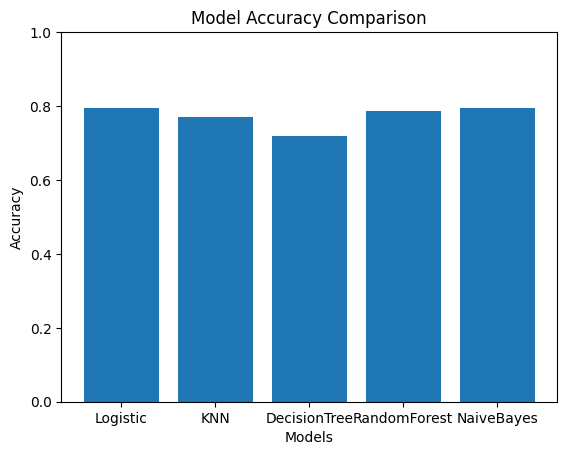

In [ ]:
models = ['Logistic', 'KNN', 'DecisionTree', 'RandomForest', 'NaiveBayes']
accuracies = [
    accuracy_score(Y_test, log_pred),
    accuracy_score(Y_test, knn_pred),
    accuracy_score(Y_test, dt_pred),
    accuracy_score(Y_test, rf_pred),
    accuracy_score(Y_test, nb_pred)
]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [ ]:
print("Logistic Regression Results: ")

log_accuracy = accuracy_score(Y_test, log_pred)
print("Accuracy:", round(log_accuracy, 4))

log_cm = confusion_matrix(Y_test, log_pred)
print("\nConfusion Matrix:\n", log_cm)

log_precision = precision_score(Y_test, log_pred)
print("\nPrecision:", round(log_precision, 4))

log_recall = recall_score(Y_test, log_pred)
print("Recall:", round(log_recall, 4))

log_f1 = f1_score(Y_test, log_pred)
print("F1 Score:", round(log_f1, 4))

print("\nClassification Report:\n")
print(classification_report(Y_test, log_pred))

print("\nNaive Bayes Results: ")

nb_accuracy = accuracy_score(Y_test, nb_pred)
print("Accuracy:", round(nb_accuracy, 4))

nb_cm = confusion_matrix(Y_test, nb_pred)
print("\nConfusion Matrix:\n", nb_cm)

nb_precision = precision_score(Y_test, nb_pred)
print("\nPrecision:", round(nb_precision, 4))

nb_recall = recall_score(Y_test, nb_pred)
print("Recall:", round(nb_recall, 4))

nb_f1 = f1_score(Y_test, nb_pred)
print("F1 Score:", round(nb_f1, 4))

print("\nClassification Report:\n")
print(classification_report(Y_test, nb_pred))


Logistic Regression Results: 
Accuracy: 0.7935

Confusion Matrix:
 [[953 219]
 [194 634]]

Precision: 0.7433
Recall: 0.7657
F1 Score: 0.7543

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.77      0.75       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000


Naive Bayes Results: 
Accuracy: 0.7935

Confusion Matrix:
 [[925 247]
 [166 662]]

Precision: 0.7283
Recall: 0.7995
F1 Score: 0.7622

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1172
           1       0.73      0.80      0.76       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.79      0.79      2000



In [ ]:
best_model = max(results, key=results.get)
print("Best Model is:", best_model)



Best Model is: Logistic Regression


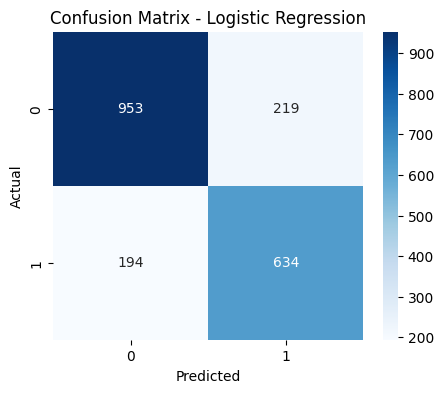

In [ ]:
#Confusion Matrix(Heatmap)

model_predictions = {
    'Logistic Regression': log_pred,
    'KNN': knn_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'Naive Bayes': nb_pred
}

best_pred = model_predictions[best_model]

cm = confusion_matrix(Y_test, best_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

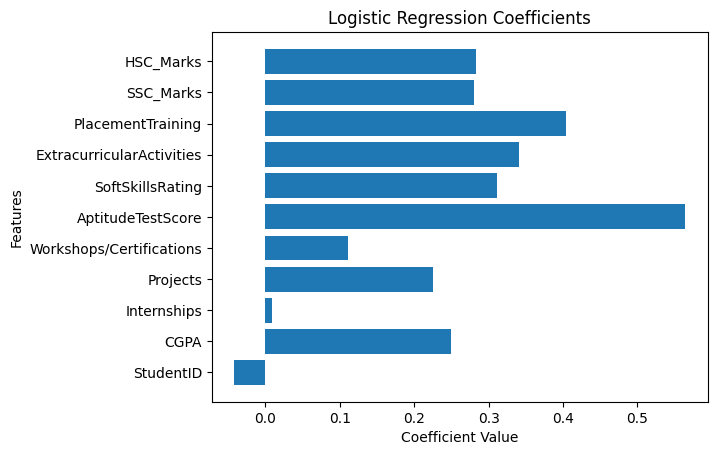

In [ ]:
#Feature Coefficient

features = X.columns
coefficients = log_model.coef_[0]

plt.barh(features, coefficients)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()